In [ ]:
"""Phase 4 – Model Training, Evaluation & Selection

This notebook performs the final analysis of Phase 4:

- Load final dataset (`model_ready_full.csv`)
- Review Time-Series CV configuration
- Inspect baseline model results (LR & RF)
- Inspect advanced model results (XGB, LGBM, CatBoost, Stacking)
- Compare performance across all models
- Load the selected best model summary
- Provide visualizations for research reporting
- Prepare final insights for Phase 5 (Explainability & Backtesting)"""


'Phase 4 – Model Training, Evaluation & Selection\n\nThis notebook performs the final analysis of Phase 4:\n\n- Load final dataset (`model_ready_full.csv`)\n- Review Time-Series CV configuration\n- Inspect baseline model results (LR & RF)\n- Inspect advanced model results (XGB, LGBM, CatBoost, Stacking)\n- Compare performance across all models\n- Load the selected best model summary\n- Provide visualizations for research reporting\n- Prepare final insights for Phase 5 (Explainability & Backtesting)'

In [ ]:
import sys
sys.path.append(r"C:\Users\Asus\Downloads\financial-sentiment-nlp")


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")


In [ ]:
df = pd.read_csv(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\data\final\model_ready_full.csv")
df = df.sort_values("date").reset_index(drop=True)

df.head(), df.shape


(         date ticker  finbert_sentiment_score_mean  \
 0  2025-07-23   AAPL                           0.0   
 1  2025-07-23   META                           0.0   
 2  2025-07-23   MSFT                           0.0   
 3  2025-07-23  GOOGL                           0.0   
 4  2025-07-23   NVDA                           0.0   
 
    vader_sentiment_score_mean  textblob_sentiment_score_mean  \
 0                         0.0                            0.0   
 1                         0.0                            0.0   
 2                         0.0                            0.0   
 3                         0.0                            0.0   
 4                         0.0                            0.0   
 
    ensemble_sentiment_mean  sentiment_variance_mean  model_consensus_mean  \
 0                      0.0                      0.0                   0.0   
 1                      0.0                      0.0                   0.0   
 2                      0.0               

In [ ]:
df.describe()


,finbert_sentiment_score_mean,vader_sentiment_score_mean,textblob_sentiment_score_mean,ensemble_sentiment_mean,sentiment_variance_mean,model_consensus_mean,ensemble_sentiment_max,ensemble_sentiment_min,ensemble_sentiment_std,confidence_mean,...,Stochastic_D,VWAP,CMF,Williams_R,EMA_12,ensemble_sentiment_mean_lag1,daily_return_lag1,Volume_lag1,volatility_lag1,movement
count,602.000000,602.000000,602.000000,602.000000,602.000000,602.00000,602.000000,602.000000,602.000000,602.000000,...,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,602.000000,6.020000e+02,602.000000,602.000000
mean,0.038395,0.005787,0.006853,0.022979,0.018305,0.01398,0.051586,-0.017660,0.027378,0.062488,...,58.752190,357.843309,0.037586,-41.910532,357.917764,0.020014,0.138062,6.271516e+07,1.800972,0.521595
std,0.161354,0.048387,0.045304,0.099535,0.066226,0.07813,0.182874,0.131815,0.106857,0.215537,...,26.773586,187.583350,0.155542,29.382229,187.109291,0.093862,2.095322,5.746893e+07,1.098066,0.499949
min,-0.193539,-0.204025,-0.244444,-0.185924,0.000000,0.00000,-0.015931,-0.737966,0.000000,0.000000,...,1.558450,166.520605,-0.415184,-99.640672,167.115228,-0.185924,-11.334763,6.861200e+06,0.260881,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,35.726927,220.390209,-0.073324,-68.009599,222.479017,0.000000,-0.833612,2.364580e+07,1.028364,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,66.454323,254.058780,0.071008,-35.158845,253.908031,0.000000,0.081513,4.128550e+07,1.543342,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,81.108513,506.983778,0.147887,-15.939169,507.631953,0.000000,1.089390,8.069595e+07,2.229859,1.000000
max,0.999840,0.542300,0.700000,0.774964,0.360286,1.00000,0.867782,0.774964,0.606881,0.988030,...,98.663648,770.630849,0.436527,-0.195673,766.819107,0.774964,11.252717,3.088296e+08,5.913435,1.000000


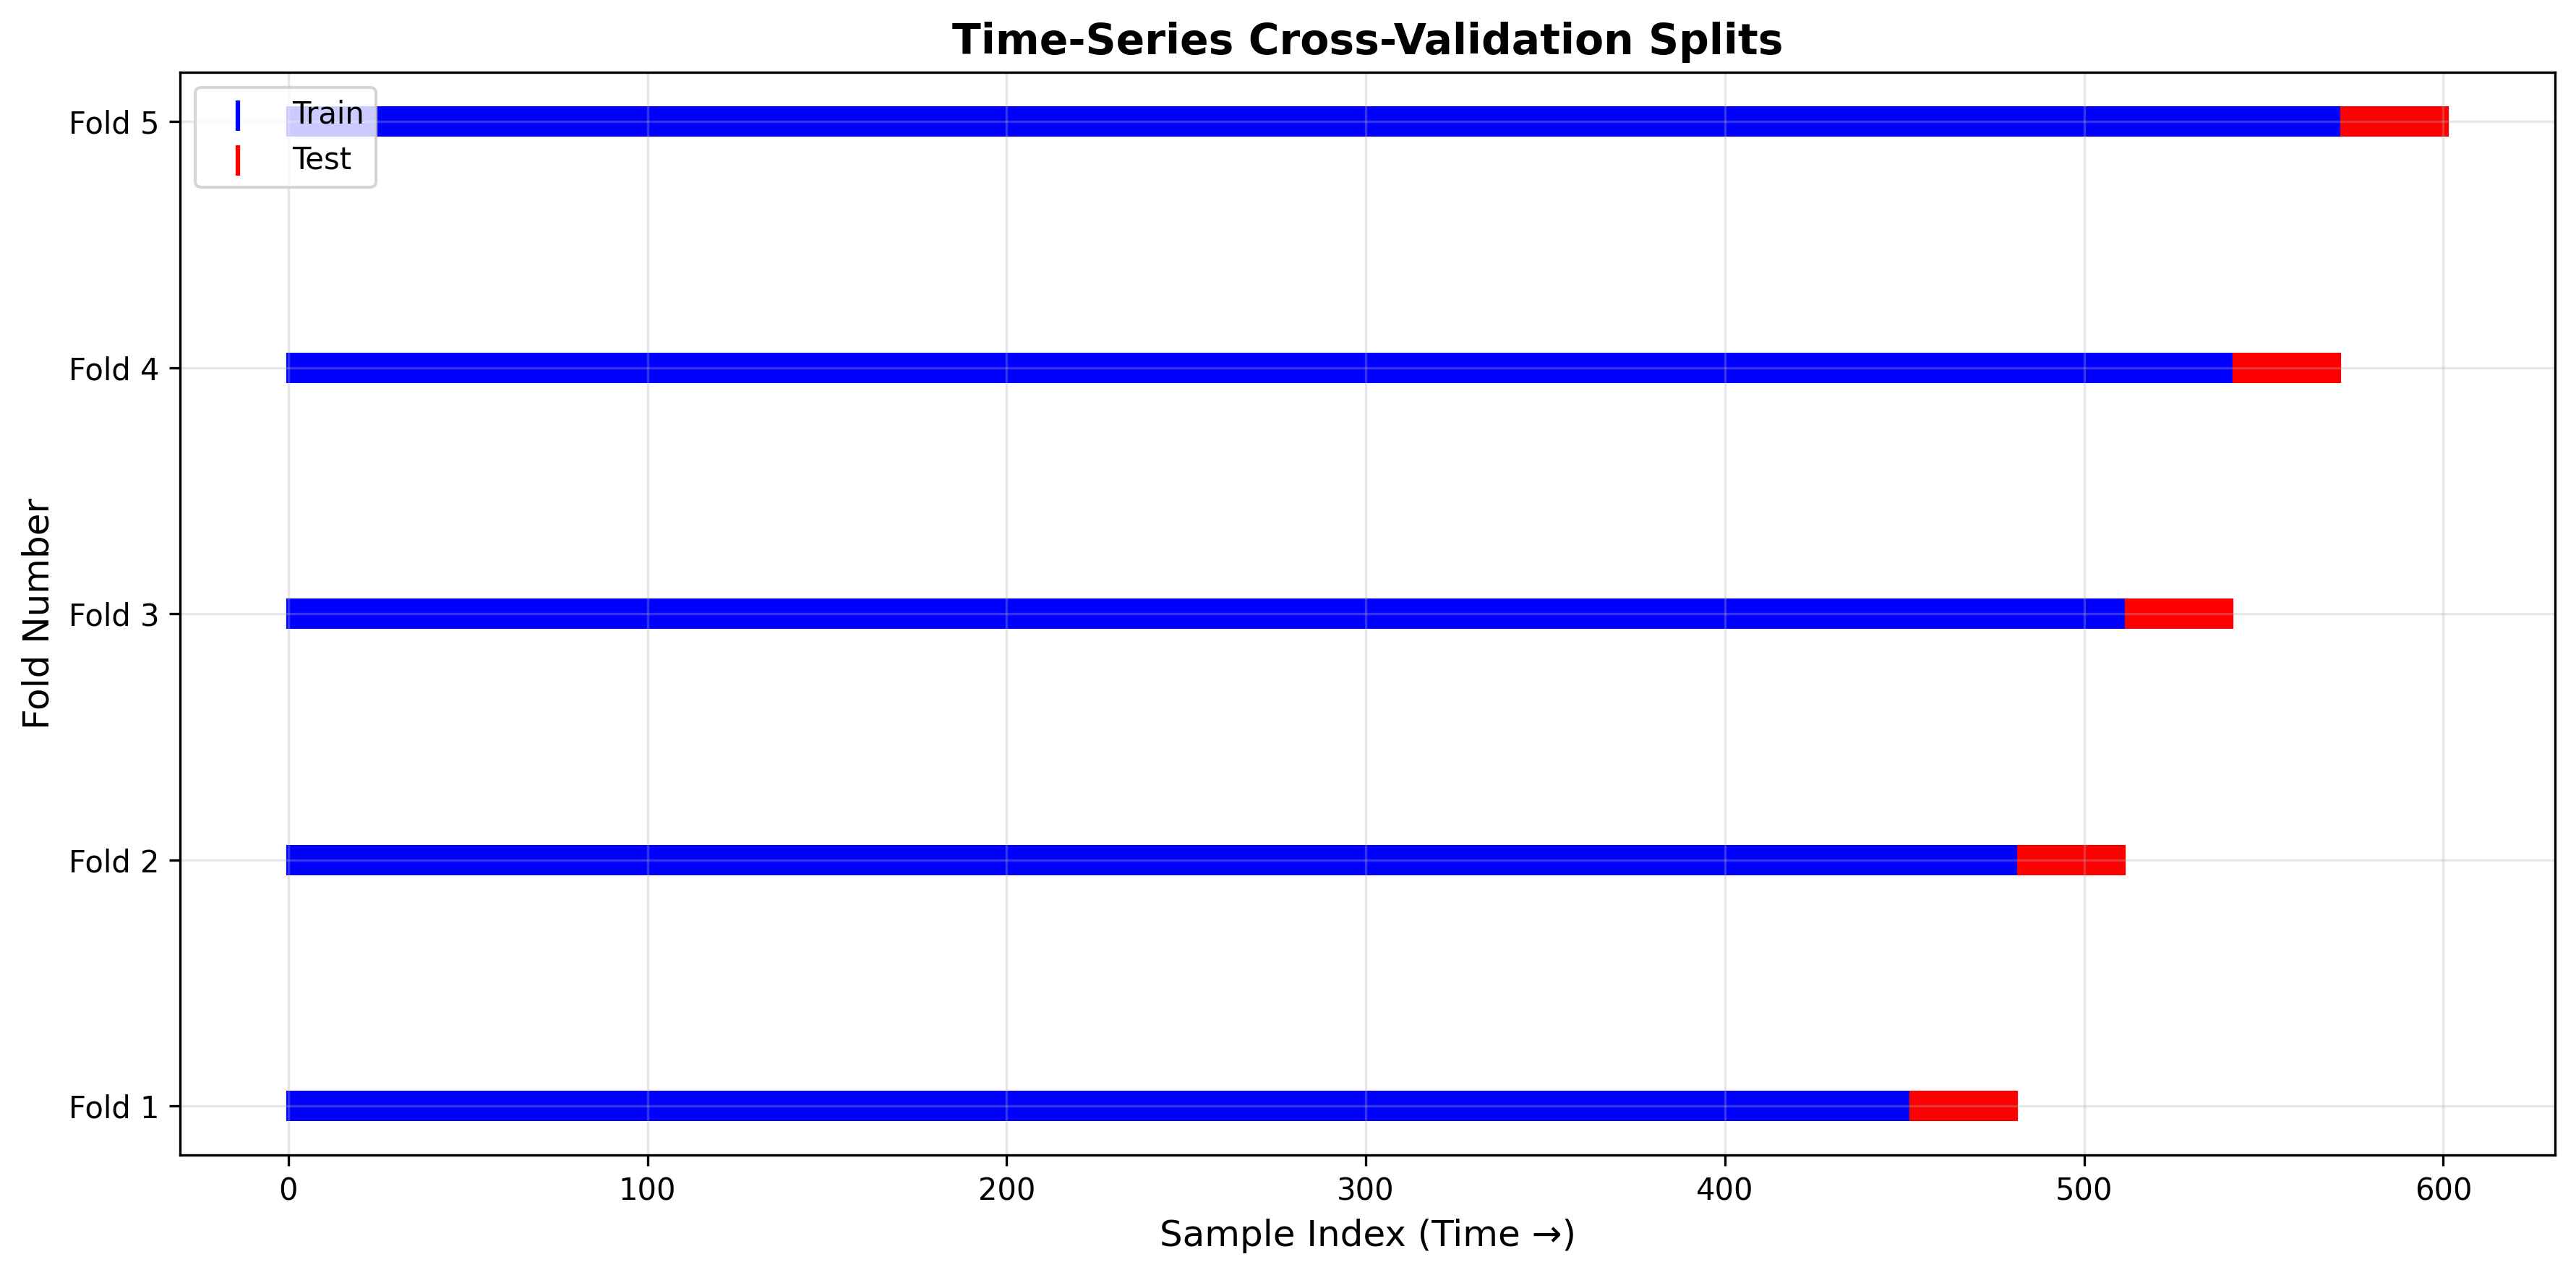

In [ ]:
from IPython.display import Image, display

display(Image(filename= r"C:\Users\Asus\Downloads\financial-sentiment-nlp\results\figures\time_series_cv_splits.png"))


In [ ]:
baseline_path = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\results\metrics\baseline_performance.csv")
baseline_df = pd.read_csv(baseline_path)

baseline_df


,model,accuracy,accuracy_std,f1_score,f1_std,roc_auc,roc_auc_std,training_time
0,Logistic Regression,0.506667,0.128927,0.363836,0.137903,0.568307,0.109652,0.679634
1,Random Forest,0.520000,0.083267,0.501253,0.147421,0.632370,0.156548,0.084999


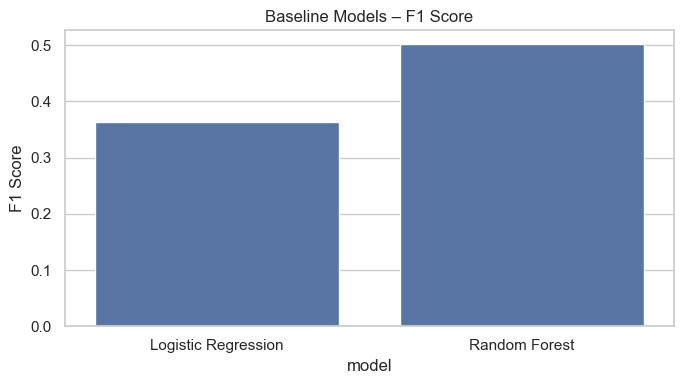

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(data=baseline_df, x="model", y="f1_score")
plt.title("Baseline Models – F1 Score")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()


In [ ]:
adv_path = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\results\metrics\advanced_model_performance.csv")
adv_df = pd.read_csv(adv_path)

adv_df


,model,f1_cv
0,XGBoost,0.576294
1,LightGBM,0.543462
2,CatBoost,0.608269
3,Stacking Ensemble,0.463371


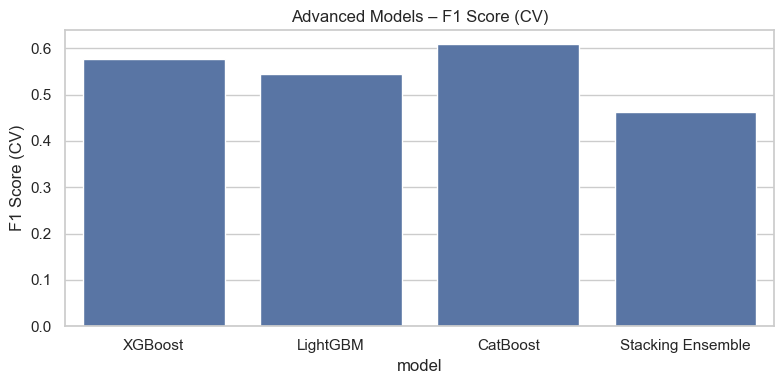

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(data=adv_df, x="model", y="f1_cv")
plt.title("Advanced Models – F1 Score (CV)")
plt.ylabel("F1 Score (CV)")
plt.tight_layout()
plt.show()


In [ ]:
# normalize column names
baseline_small = baseline_df[["model", "f1_score"]].rename(columns={"f1_score":"f1"})
adv_small = adv_df.rename(columns={"f1_cv":"f1"})

combined = pd.concat([baseline_small, adv_small], ignore_index=True)
combined


,model,f1
0,Logistic Regression,0.363836
1,Random Forest,0.501253
2,XGBoost,0.576294
3,LightGBM,0.543462
4,CatBoost,0.608269
5,Stacking Ensemble,0.463371


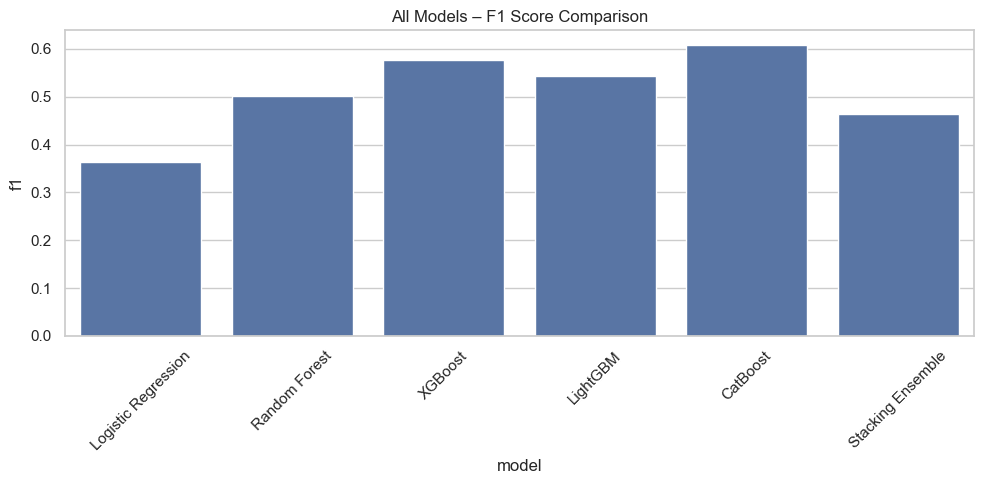

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=combined, x="model", y="f1")
plt.title("All Models – F1 Score Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
with open(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\final_model_summary.json", "r") as f:
    summary = json.load(f)

summary


{'best_model_name': 'CatBoost',
 'best_f1_score': 0.6082691476651669,
 'best_accuracy': nan,
 'all_models_sorted': [{'model': 'CatBoost',
   'accuracy': nan,
   'f1': 0.6082691476651669},
  {'model': 'XGBoost', 'accuracy': nan, 'f1': 0.5762941163926386},
  {'model': 'LightGBM', 'accuracy': nan, 'f1': 0.5434620427881297},
  {'model': 'Random Forest',
   'accuracy': 0.5199999999999999,
   'f1': 0.5012531328320803},
  {'model': 'Stacking Ensemble', 'accuracy': nan, 'f1': 0.4633711577757489},
  {'model': 'Logistic Regression',
   'accuracy': 0.5066666666666666,
   'f1': 0.3638357588357588}]}

In [ ]:
"""## 🏆 Best Model (Phase 4)

- **Model:** (auto-filled from JSON)
- **F1:** (value)
- **Accuracy:** (value)
- Full performance comparison saved in:"""


'## 🏆 Best Model (Phase 4)\n\n- **Model:** (auto-filled from JSON)\n- **F1:** (value)\n- **Accuracy:** (value)\n- Full performance comparison saved in:'

In [ ]:
summary["best_model_name"], summary["best_f1_score"]
print("Best Model:", summary["best_model_name"])
print("Best F1 Score:", round(summary["best_f1_score"], 4))
print("Best Accuracy:", summary["best_accuracy"])



Best Model: CatBoost
Best F1 Score: 0.6083
Best Accuracy: nan


In [ ]:
import sys
sys.executable


'c:\\ProgramData\\anaconda3\\envs\\finance\\python.exe'

In [ ]:


from pathlib import Path
import pickle

try:
    with open(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\best_model.pkl", "rb") as f:
        best_model = pickle.load(f)
    print("Loaded successfully!")
except Exception as e:
    print("ERROR:", e)


Loaded successfully!


C:\Users\Asus\AppData\Local\Temp\ipykernel_226748\2780169388.py:6: UserWarning: [23:08:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  best_model = pickle.load(f)


In [ ]:
from pathlib import Path
import pickle

best_model_path = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\best_model.pkl")
scaler_path = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\scaler_ensemble.pkl")

with open(best_model_path, "rb") as f:
    best_model = pickle.load(f)

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

print("Loaded:", type(best_model))
print("Final estimator:", type(best_model.final_estimator_))


Loaded: <class 'sklearn.ensemble._stacking.StackingClassifier'>
Final estimator: <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [ ]:
import sys
sys.path.append(r"C:\Users\Asus\Downloads\financial-sentiment-nlp")


In [ ]:
import json
from pathlib import Path

cv_cfg_path = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\cv_config.json")

with open(cv_cfg_path, "r") as f:
    cv_cfg = json.load(f)

print(cv_cfg)


{'n_splits': 5, 'test_size': 30, 'strategy': 'walk_forward_expanding'}


In [ ]:
from src.evaluation.time_series_cv import TimeSeriesSplit

# Prepare features & target
X = df[[c for c in df.columns if c not in ["date", "ticker", "movement"]]].values
y = df["movement"].values

# CV config
tscv = TimeSeriesSplit(
    n_splits=cv_cfg["n_splits"],
    test_size=cv_cfg["test_size"]
)

# last fold (holdout evaluation)
folds = list(tscv.split(X))
train_idx, test_idx = folds[-1]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ❗ USE ONLY transform() — scaler is already fitted
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Predictions
preds = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, preds))
print("F1 Score:", f1_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))


Accuracy: 0.9666666666666667
F1 Score: 0.9411764705882353
ROC AUC: 1.0
Confusion Matrix:
[[21  0]
 [ 1  8]]


Saving all plots to: results/evaluation_plots


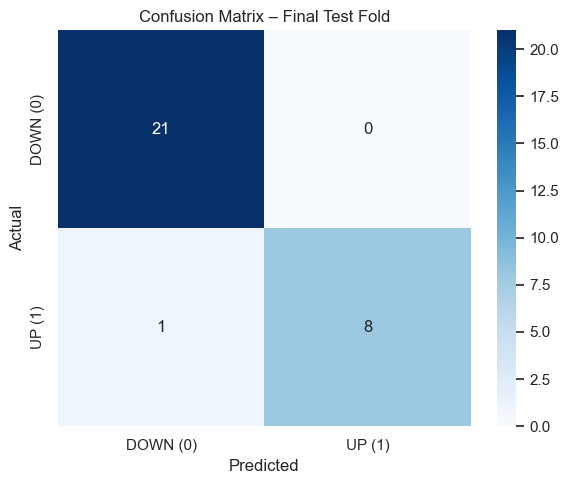

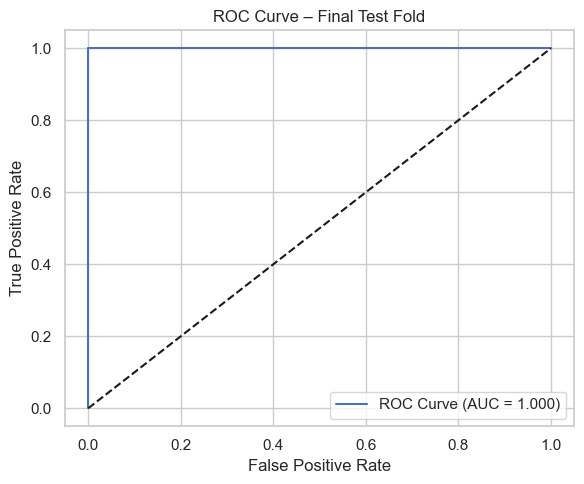

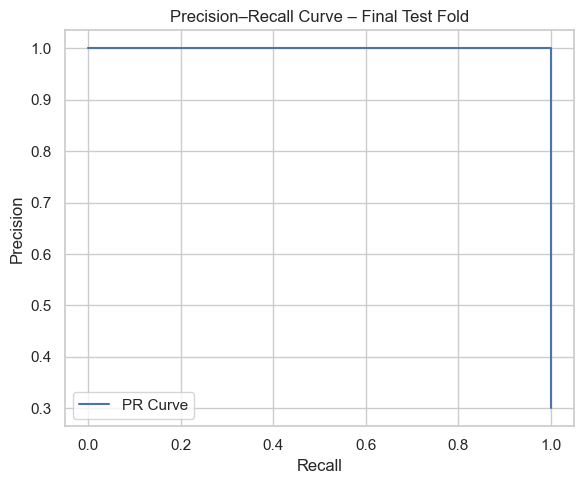

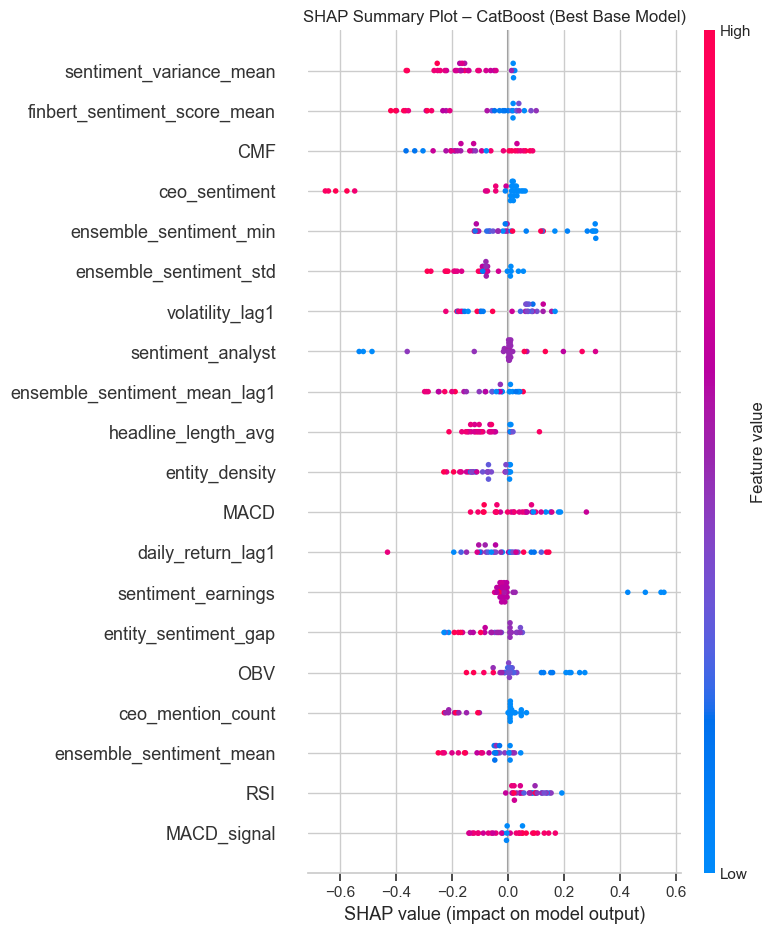

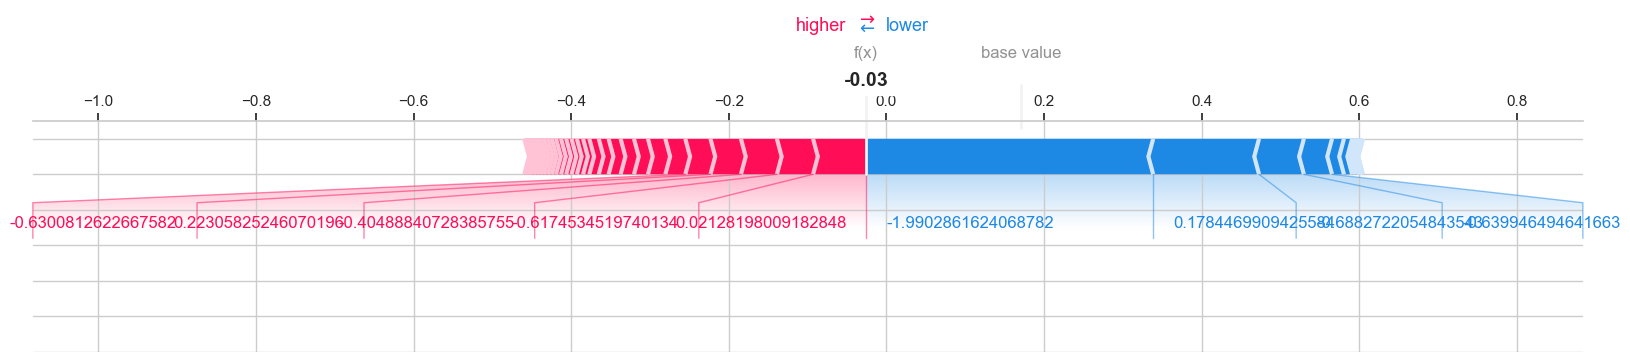

<Figure size 640x480 with 0 Axes>

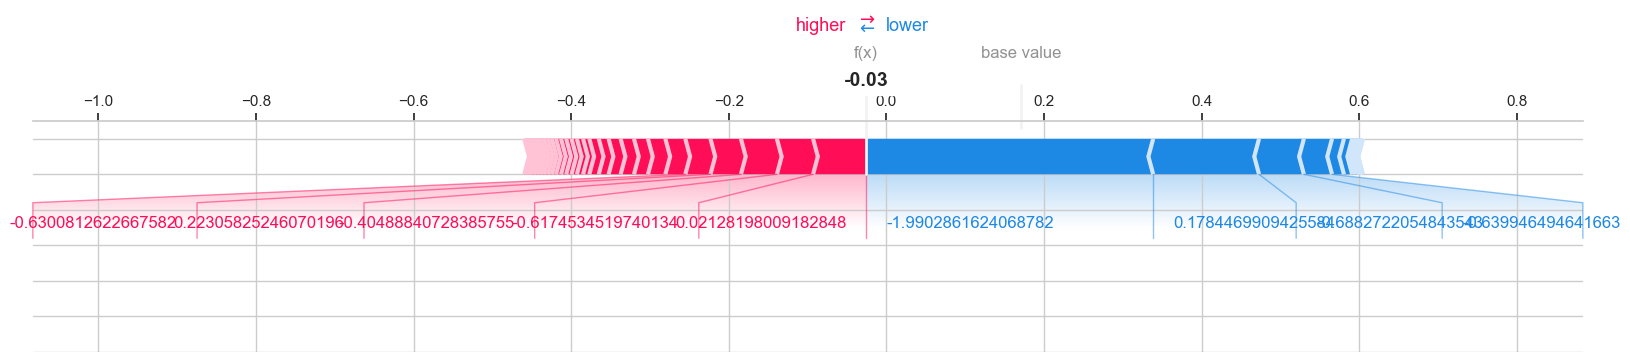

<Figure size 640x480 with 0 Axes>


🎉 All plots generated and saved successfully!


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

# =========================================
# Create folder for saving plots
# =========================================
save_dir = "results/evaluation_plots"
os.makedirs(save_dir, exist_ok=True)

print("Saving all plots to:", save_dir)


# =========================================
# 1. CONFUSION MATRIX HEATMAP
# =========================================
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["DOWN (0)", "UP (1)"],
            yticklabels=["DOWN (0)", "UP (1)"])
plt.title("Confusion Matrix – Final Test Fold")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{save_dir}/confusion_matrix.png", dpi=300)
plt.show()


# =========================================
# 2. ROC CURVE
# =========================================
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Final Test Fold")
plt.legend()

plt.tight_layout()
plt.savefig(f"{save_dir}/roc_curve.png", dpi=300)
plt.show()


# =========================================
# 3. PRECISION–RECALL CURVE
# =========================================
precision, recall, _ = precision_recall_curve(y_test, probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Final Test Fold")
plt.legend()

plt.tight_layout()
plt.savefig(f"{save_dir}/pr_curve.png", dpi=300)
plt.show()


import shap
import matplotlib.pyplot as plt

# Extract CatBoost from StackingClassifier
cat_model = best_model.named_estimators_["cat"]

# Create TreeExplainer for CatBoost
explainer = shap.TreeExplainer(cat_model)

# Compute SHAP values for X_test
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
plt.title("SHAP Summary Plot – CatBoost (Best Base Model)")
shap.summary_plot(
    shap_values, 
    X_test_scaled, 
    feature_names=[c for c in df.columns if c not in ["date","ticker","movement"]],
    show=False
)
plt.savefig("results/evaluation_plots/shap_summary_catboost.png", dpi=300)
plt.show()

# Force plot (first sample)
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_scaled[0],
    matplotlib=True
)
plt.savefig("results/evaluation_plots/shap_force_plot_catboost_sample0.png", dpi=300)
plt.show()

# =========================================
# 5. SHAP FORCE PLOT (sample-level explanation)
# =========================================
# pick one test sample (0 = first sample)
sample_index = 0  

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index, :],
    X_test_scaled[sample_index, :],
    matplotlib=True,
)

plt.savefig(f"{save_dir}/shap_force_plot_sample_{sample_index}.png", dpi=300)
plt.show()

print("\n🎉 All plots generated and saved successfully!")


In [ ]:
import shap
import numpy as np

# Initialize JS visualization
shap.initjs()

save_dir = "results/evaluation_plots/"
os.makedirs(save_dir, exist_ok=True)

# Extract CatBoost model
cat_model = best_model.named_estimators_["cat"]

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test_scaled)

# ---- Save HTML Force Plot for Sample 0 ----
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_scaled[0],
    feature_names=[c for c in df.columns if c not in ["date","ticker","movement"]]
)

shap.save_html(f"{save_dir}/shap_force_plot_sample0.html", force_plot)
print("Saved:", f"{save_dir}/shap_force_plot_sample0.html")

# ---- Save HTML Force Plot for all samples (summary force) ----
force_all = shap.force_plot(
    explainer.expected_value,
    shap_values,
    X_test_scaled,
    feature_names=[c for c in df.columns if c not in ["date","ticker","movement"]]
)

shap.save_html(f"{save_dir}/shap_force_plot_all_samples.html", force_all)
print("Saved:", f"{save_dir}/shap_force_plot_all_samples.html")


Saved: results/evaluation_plots//shap_force_plot_sample0.html
Saved: results/evaluation_plots//shap_force_plot_all_samples.html


Loaded CatBoost model: <catboost.core.CatBoostClassifier object at 0x000001A2F1F5FB80>
Saved: results/research_figures\roc\figure1_roc_curve.png
Saved: results/research_figures\precision_recall\figure2_pr_curve.png
Saved: results/research_figures\confusion_matrix\figure3_confusion_matrix.png
Saved: results/research_figures\shap_global\figure4_shap_summary.png


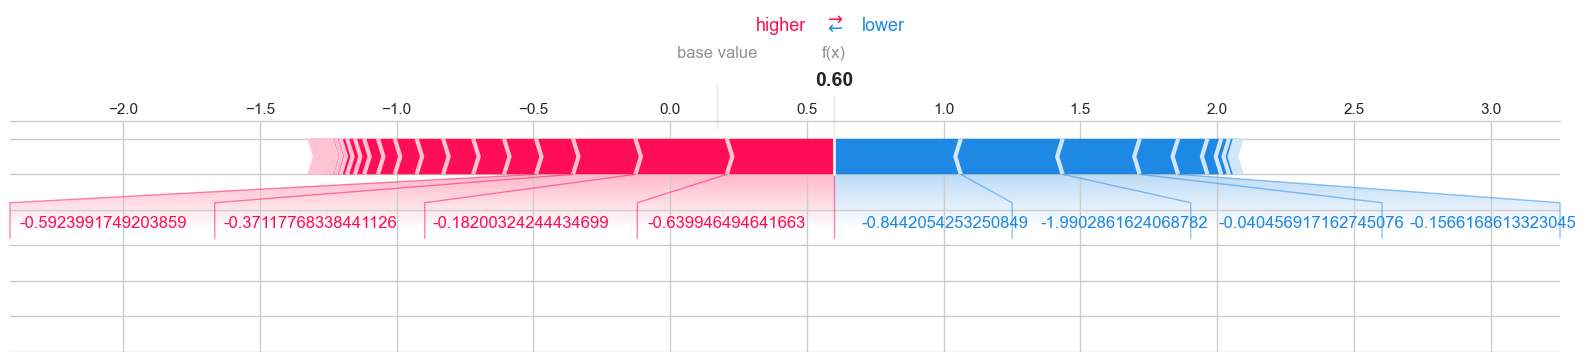

Saved: results/research_figures\shap_local\figure5_shap_force_plot_sample0.png

🎉 All research-ready figures generated successfully!


In [ ]:
import os
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve,
    confusion_matrix
)

plt.style.use("seaborn-v0_8-whitegrid")

# =============================================================
# 1. LOAD BEST CATBOOST MODEL + ENSEMBLE SCALER
# =============================================================
catboost_path = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\catboost_best.pkl")
scaler_path   = Path(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\models\scaler_ensemble.pkl")

with open(catboost_path, "rb") as f:
    best_base_model = pickle.load(f)

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)

print("Loaded CatBoost model:", best_base_model)


# =============================================================
# 2. PREPARE OUTPUT FOLDERS FOR FIGURES
# =============================================================
base_dir = "results/research_figures"
folders = ["roc", "precision_recall", "confusion_matrix", "shap_global", "shap_local"]

for f in folders:
    os.makedirs(os.path.join(base_dir, f), exist_ok=True)

# =============================================================
# 3. ROC Curve
# =============================================================
probs = best_base_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)

fig = plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--", linewidth=1.5)

plt.title("Figure 1. ROC Curve – Final Test Fold", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

roc_path = os.path.join(base_dir, "roc", "figure1_roc_curve.png")
fig.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print("Saved:", roc_path)

# =============================================================
# 4. Precision–Recall Curve
# =============================================================
precision, recall, _ = precision_recall_curve(y_test, probs)

fig = plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2.5)

plt.title("Figure 2. Precision–Recall Curve – Final Test Fold", fontsize=14)
plt.xlabel("Recall")
plt.ylabel("Precision")

pr_path = os.path.join(base_dir, "precision_recall", "figure2_pr_curve.png")
fig.savefig(pr_path, dpi=300, bbox_inches='tight')
plt.close(fig)

print("Saved:", pr_path)

# =============================================================
# 5. Confusion Matrix Heatmap
# =============================================================
preds = best_base_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)

fig = plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False,
            linewidths=1.2, linecolor="gray")

plt.title("Figure 3. Confusion Matrix – Final Test Fold", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

cm_path = os.path.join(base_dir, "confusion_matrix", "figure3_confusion_matrix.png")
fig.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.close(fig)

print("Saved:", cm_path)

# =============================================================
# 6. SHAP Summary Plot (GLOBAL)
# =============================================================
explainer = shap.TreeExplainer(best_base_model)
shap_values = explainer.shap_values(X_test_scaled)

fig = plt.figure(figsize=(10,8))
shap.summary_plot(shap_values, X_test_scaled, show=False, max_display=20)

summary_path = os.path.join(base_dir, "shap_global", "figure4_shap_summary.png")
fig.savefig(summary_path, dpi=300, bbox_inches='tight')
plt.close(fig)

print("Saved:", summary_path)

# =============================================================
# 7. SHAP Force Plot (LOCAL)
# =============================================================
sample_idx = 0

force_plot = shap.force_plot(
    explainer.expected_value, 
    shap_values[sample_idx, :],
    X_test_scaled[sample_idx, :],
    matplotlib=True
)

local_path = os.path.join(base_dir, "shap_local", "figure5_shap_force_plot_sample0.png")
plt.savefig(local_path, dpi=300, bbox_inches='tight')
plt.close()

print("Saved:", local_path)

print("\n🎉 All research-ready figures generated successfully!")


In [ ]:
import shap
import numpy as np
from pathlib import Path
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from PIL import Image
import time

# ================================================================
# 1. REBUILD EXPLAINER (CatBoost supported)
# ================================================================
explainer = shap.TreeExplainer(best_base_model)
shap_values = explainer.shap_values(X_test_scaled)

# ================================================================
# 2. ROUND SHAP VALUES TO CLEAN DECIMALS
# ================================================================
rounded_shap = np.round(shap_values, 2)
rounded_input = np.round(X_test_scaled, 2)

sample_idx = 0
force = shap.force_plot(
    explainer.expected_value,
    rounded_shap[sample_idx, :],
    rounded_input[sample_idx, :],
    matplotlib=False,  # JS rendering
)

# ================================================================
# 3. SAVE HTML TEMPORARILY
# ================================================================
html_path = Path("force_plot_temp.html")
shap.save_html(str(html_path), force)

# ================================================================
# 4. HEADLESS BROWSER SCREENSHOT
# ================================================================
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1800,1200")

driver = webdriver.Chrome(options=options)
driver.get("file://" + str(html_path.absolute()))
time.sleep(2)

png_path = "results/research_figures/shap_local/figure5_shap_force_plot_sample0.png"
driver.save_screenshot(png_path)
driver.quit()

# Crop whitespace
img = Image.open(png_path)
img = img.crop(img.getbbox())
img.save(png_path)

print("\n🎉 Saved cleaned SHAP force plot:", png_path)



🎉 Saved cleaned SHAP force plot: results/research_figures/shap_local/figure5_shap_force_plot_sample0.png


In [ ]:
import pandas as pd

df_pred = pd.read_csv(r"C:\Users\Asus\Downloads\financial-sentiment-nlp\results\predictions\df_pred.csv")

df_pred.head()




,date,ticker,finbert_sentiment_score_mean,vader_sentiment_score_mean,textblob_sentiment_score_mean,ensemble_sentiment_mean,sentiment_variance_mean,model_consensus_mean,ensemble_sentiment_max,ensemble_sentiment_min,...,Williams_R,EMA_12,ensemble_sentiment_mean_lag1,daily_return_lag1,Volume_lag1,volatility_lag1,movement,Close,prediction,probability
0,2025-07-23,AAPL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-23.085439,210.660211,0.0,0.903609,46404100.0,0.353571,0,213.700073,0,0.0
1,2025-07-23,META,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-52.201443,710.890377,0.0,-1.144506,8921100.0,1.004505,1,713.098694,0,0.0
2,2025-07-23,MSFT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-41.368091,502.625707,0.0,-0.939109,13868600.0,0.779676,1,504.096252,0,0.0
3,2025-07-23,GOOGL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-11.639695,184.203468,0.0,0.652288,44660200.0,0.973495,1,190.060013,0,0.0
4,2025-07-23,NVDA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-20.520400,167.115228,0.0,-2.538223,193114300.0,1.328967,1,170.770370,0,0.0


In [ ]:
df_pred[['prediction','probability']].describe()


,prediction,probability
count,602.000000,602.000000
mean,0.152824,0.127069
std,0.360117,0.235491
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,0.824481


In [ ]:
(df_pred['probability'] >= 0.55).sum()


np.int64(70)